In [4]:
import os
import re

import glob
import json
from typing import Dict, List, Tuple, Optional, Sequence, Any
from collections import OrderedDict
from copy import deepcopy
from dataclasses import dataclass

import numpy as np
import xarray as xr
import hashlib

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.transforms as mtransforms
from matplotlib.patches import Rectangle

from pcmdi_enso_reader import (
    ENSOMetricReader,
    ENSODiagReader
)

In [5]:
class ENSOMetricSubset:
    def __init__(
        self,
        out: Dict[str, Any],
        metric_collections: Sequence[str],
        met_names: Dict[str, str],
    ):
        self.out = out
        self.metric_collections = list(metric_collections)
        self.met_names = met_names or {}

    @staticmethod
    def _canon(s: str) -> str:
        return str(s).strip().lower()

    def y_names(self) -> List[str]:
        return list(self.out.get("y_names", []))

    def extract_subset(
        self,
        metrics_ordered: "Dict[str, str]",
        which: str = "raw",   # "raw" or "norm"
        *,
        keep_first_duplicate: bool = True,
        debug: bool = False,
        return_out: bool = False,
        include_other_tab: bool = False,   # if True, also include the other tab_* for convenience
    ):
        """
        Returns
        -------
        subset : dict[mc -> masked_array]
        subset_keys : dict[mc -> list[str]]    # canonical ids (your metrics_ordered keys) found
        subset_labels : dict[mc -> list[str]]  # pretty labels aligned with subset_keys
        out_sub : dict (optional)
            Contains:
              - y_names, x_names
              - tab: list[masked_array]  (the selected one: raw OR norm)
              - tab_raw OR tab_norm (matching `which`)
              - ref_info (carried through)
            If include_other_tab=True, also includes the other one.
        """
        if which not in ("raw", "norm"):
            raise ValueError("which must be 'raw' or 'norm'")

        tabs_raw = self.out["tab_raw"]
        tabs_norm = self.out["tab_norm"]
        x_all = self.out["x_names"]

        # canonical-safe pretty-label dict (avoids KeyError due to case differences)
        ordered_pretty_by_canon = {self._canon(k): v for k, v in metrics_ordered.items()}
        want_canon = [self._canon(k) for k in metrics_ordered.keys()]  # requested order

        subset: Dict[str, np.ma.MaskedArray] = {}
        subset_keys: Dict[str, List[str]] = {}
        subset_labels: Dict[str, List[str]] = {}

        # for out_sub (if requested)
        x_sub_all: List[List[str]] = []
        tab_raw_sub_all: List[np.ma.MaskedArray] = []
        tab_norm_sub_all: List[np.ma.MaskedArray] = []

        for k, mc in enumerate(self.metric_collections):
            x = list(x_all[k])         # JSON metric keys in this group
            tab_r = tabs_raw[k]
            tab_n = tabs_norm[k]

            idx_by_canon: Dict[str, int] = {}
            dupes: Dict[str, List[int]] = {}
            jsonkey_by_canon: Dict[str, str] = {}

            for j, met_key in enumerate(x):
                canon_id = self._canon(self.met_names.get(met_key, met_key))
                if canon_id in idx_by_canon:
                    dupes.setdefault(canon_id, [idx_by_canon[canon_id]]).append(j)
                    if not keep_first_duplicate:
                        idx_by_canon[canon_id] = j
                        jsonkey_by_canon[canon_id] = met_key
                else:
                    idx_by_canon[canon_id] = j
                    jsonkey_by_canon[canon_id] = met_key

            # Select columns in requested order
            sub_canon = [cid for cid in want_canon if cid in idx_by_canon]
            cols = [idx_by_canon[cid] for cid in sub_canon]

            sub_tab_raw = tab_r[:, cols]
            sub_tab_norm = tab_n[:, cols]

            sub_pretty = [ordered_pretty_by_canon[cid] for cid in sub_canon]
            sub_json_keys = [jsonkey_by_canon[cid] for cid in sub_canon]

            subset[mc] = sub_tab_raw if which == "raw" else sub_tab_norm
            subset_keys[mc] = sub_canon
            subset_labels[mc] = sub_pretty

            if return_out:
                x_sub_all.append(sub_json_keys)
                tab_raw_sub_all.append(sub_tab_raw)
                tab_norm_sub_all.append(sub_tab_norm)

            if debug:
                missing = [cid for cid in want_canon if cid not in idx_by_canon]
                if missing:
                    print(f"[{mc}] missing {len(missing)} metrics: {missing}")
                if dupes:
                    kept = "first" if keep_first_duplicate else "last"
                    print(f"[{mc}] duplicates (kept {kept}): {dupes}")
                print(f"[{mc}] selected {len(cols)} metrics.")

        if not return_out:
            return subset, subset_keys, subset_labels

        out_sub: Dict[str, Any] = {
            "y_names": list(self.out["y_names"]),
            "ref_info": self.out.get("ref_info", {}),
            "x_names": x_sub_all,
        }

        # unified tab key
        if which == "raw":
            out_sub["tab"] = tab_raw_sub_all
            out_sub["tab_raw"] = tab_raw_sub_all
            if include_other_tab:
                out_sub["tab_norm"] = tab_norm_sub_all
        else:
            out_sub["tab"] = tab_norm_sub_all
            out_sub["tab_norm"] = tab_norm_sub_all
            if include_other_tab:
                out_sub["tab_raw"] = tab_raw_sub_all

        return subset, subset_keys, subset_labels, out_sub


In [31]:
class ENSOOutSubRelativePlotterMulti:
    """
    Relative metric plotter with a configurable baseline ensemble.

    General definition:
      rel(model) = |m_model - obs| / mean_{baseline group} |m_i - obs|

    Typical use for HIST vs FUTURE:
      baseline_group = "HIST"
      model_groups = {
          "HIST":   r"...hist...",
          "FUTURE": r"...future...",
      }

    Required out_sub schema:
      out_sub['y_names'] : list[str]
      out_sub['x_names'] : list[list[str]]        # per metric_collection
      out_sub['tab']     : list[masked_array]     # per metric_collection (already chosen raw/norm)
    """

    def __init__(
        self,
        out_sub: Dict[str, Any],
        *,
        model_groups: Dict[str, str],   # name -> include-regex
        baseline_group: str,            # must be one key in model_groups
        reference_regex: str = r"^\(reference\)$",
    ):
        self.out = out_sub

        self._re_ref = re.compile(reference_regex)
        self._re_groups = {name: re.compile(pat) for name, pat in model_groups.items()}

        self.y_names: List[str] = list(out_sub.get("y_names", []))
        self.group_xnames: List[List[str]] = list(out_sub.get("x_names", []))
        self.group_tabs: List[np.ma.MaskedArray] = list(out_sub.get("tab", []))

        if len(self.group_xnames) != len(self.group_tabs):
            raise ValueError("out_sub['x_names'] and out_sub['tab'] must have same length")

        # --- reference row ---
        idx_ref = [i for i, y in enumerate(self.y_names) if self._re_ref.search(y)]
        if len(idx_ref) != 1:
            raise ValueError(
                f"Expected exactly 1 reference row matching {reference_regex}, got {len(idx_ref)}: {idx_ref}"
            )
        self.idx_ref = idx_ref[0]

        # --- group rows ---
        self.idx_groups: Dict[str, List[int]] = {}
        for name, rr in self._re_groups.items():
            idx = [i for i, y in enumerate(self.y_names) if rr.search(y)]
            if len(idx) == 0:
                raise ValueError(f"No rows matched group '{name}' regex: {rr.pattern}")
            self.idx_groups[name] = idx

        if baseline_group not in self.idx_groups:
            raise ValueError(
                f"baseline_group '{baseline_group}' is not a valid model group. "
                f"Available groups: {list(self.idx_groups.keys())}"
            )

        self.baseline_group = baseline_group
        self.idx_baseline = self.idx_groups[baseline_group]

    @staticmethod
    def _canon(s: str) -> str:
        return str(s).strip().lower()

    @staticmethod
    def _masked_to_float(a) -> np.ndarray:
        if isinstance(a, np.ma.MaskedArray):
            return a.astype(float).filled(np.nan)
        return np.asarray(a, dtype=float)

    @staticmethod
    def _bootstrap_ci_mean(
        x: np.ndarray,
        n_mc: int = 5000,
        alpha: float = 0.05,
        seed: int = 0,
    ) -> Tuple[float, float, float]:
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        if x.size == 0:
            return np.nan, np.nan, np.nan
        if x.size == 1:
            m = float(x[0])
            return m, m, m
        rng = np.random.default_rng(seed)
        idx = rng.integers(0, x.size, size=(n_mc, x.size))
        means = x[idx].mean(axis=1)
        m = float(x.mean())
        lo = float(np.percentile(means, 100 * (alpha / 2)))
        hi = float(np.percentile(means, 100 * (1 - alpha / 2)))
        return m, lo, hi

    @staticmethod
    def _mc_ci_mean_t(
        x: np.ndarray,
        n_mc: int = 20000,
        alpha: float = 0.05,
        seed: int = 0,
    ) -> Tuple[float, float, float]:
        """
        Parametric Monte-Carlo CI for the mean.
        Uses t_{n-1} if SciPy is available; otherwise falls back to Normal approx.
        """
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        n = x.size
        if n == 0:
            return np.nan, np.nan, np.nan
        m = float(x.mean())
        if n == 1:
            return m, m, m

        s = float(x.std(ddof=1))
        se = s / np.sqrt(n)
        rng = np.random.default_rng(seed)

        try:
            from scipy.stats import t as tdist
            t_draw = tdist.rvs(df=n - 1, size=n_mc, random_state=rng)
        except Exception:
            t_draw = rng.standard_normal(n_mc)

        mean_draw = m + t_draw * se
        lo = float(np.quantile(mean_draw, alpha / 2))
        hi = float(np.quantile(mean_draw, 1 - alpha / 2))
        return m, lo, hi

    @staticmethod
    def _seed32(base_seed: int, metric_i: int, group: str, method: str) -> int:
        """
        Stable 32-bit seed derived from semantic identifiers.
        """
        s = f"{base_seed}|{metric_i}|{group}|{method}".encode("utf-8")
        return int(hashlib.sha256(s).hexdigest()[:8], 16)

    def _flatten_metrics_in_order(
        self,
        metrics_ordered: "Dict[str, str]",
        *,
        met_names: Optional[Dict[str, str]] = None,
        keep_first_duplicate: bool = True,
        debug: bool = False,
    ) -> Tuple[List[Tuple[int, int]], List[str]]:
        met_names = met_names or {}

        want_keys = [self._canon(k) for k in metrics_ordered.keys()]
        want_lbls = [metrics_ordered[k] for k in metrics_ordered.keys()]

        where: Dict[str, Tuple[int, int]] = {}
        dupes: Dict[str, List[Tuple[int, int]]] = {}

        for g, xnames in enumerate(self.group_xnames):
            for j, mk in enumerate(xnames):
                cid = self._canon(met_names.get(mk, mk))
                if cid in where:
                    dupes.setdefault(cid, [where[cid]]).append((g, j))
                    if not keep_first_duplicate:
                        where[cid] = (g, j)
                else:
                    where[cid] = (g, j)

        locs, labels, missing = [], [], []
        for cid, lbl in zip(want_keys, want_lbls):
            if cid in where:
                locs.append(where[cid])
                labels.append(lbl)
            else:
                missing.append(cid)

        if debug:
            if missing:
                print(f"[plotter] missing {len(missing)} metrics: {missing}")
            if dupes:
                kept = "first" if keep_first_duplicate else "last"
                print(f"[plotter] duplicates (kept {kept}): {dupes}")

        return locs, labels

    def compute_relative(
        self,
        metrics_ordered: "Dict[str, str]",
        *,
        met_names: Optional[Dict[str, str]] = None,
        keep_first_duplicate: bool = True,
        debug: bool = False,
    ) -> Tuple[List[str], np.ndarray, Dict[str, List[np.ndarray]]]:
        locs, labels = self._flatten_metrics_in_order(
            metrics_ordered,
            met_names=met_names,
            keep_first_duplicate=keep_first_duplicate,
            debug=debug,
        )

        n = len(locs)
        denom_arr = np.full(n, np.nan)
        group_rel: Dict[str, List[np.ndarray]] = {k: [] for k in self.idx_groups.keys()}

        for i, (g, j) in enumerate(locs):
            tab = self._masked_to_float(self.group_tabs[g])

            obs = tab[self.idx_ref, j]

            base = tab[self.idx_baseline, j]
            d_base = np.abs(base - obs)
            d_base = d_base[np.isfinite(d_base)]
            denom = float(np.nanmean(d_base)) if d_base.size else np.nan
            denom_arr[i] = denom

            for name, idx in self.idx_groups.items():
                vals = tab[idx, j]
                if not np.isfinite(denom) or denom == 0:
                    rel = np.full_like(vals, np.nan, dtype=float)
                else:
                    rel = np.abs(vals - obs) / denom
                group_rel[name].append(rel)

        return labels, denom_arr, group_rel

    def list_models(self) -> Dict[str, List[str]]:
        out: Dict[str, List[str]] = {}
        for gname, idxs in self.idx_groups.items():
            out[gname] = [self.y_names[i] for i in idxs]
        return out

    def _label_color_from_category(self, label: str, category_spec):
        lab = str(label).lower()
        for _cat, keys, color in category_spec:
            if any(str(k).lower() in lab for k in keys):
                return color
        return None

    def plot(
        self,
        metrics_ordered: "Dict[str, str]",
        *,
        met_names: Optional[Dict[str, str]] = None,
        title: str = "Metric values relative to observations (baseline-normalized)",
        show_group_members: bool = False,
        show_means_and_ci: bool = True,
        n_mc: int = 5000,
        alpha: float = 0.05,
        figsize: Tuple[float, float] = (13.5, 4.6),
        dpi: int = 160,
        dodge: float = 0.18,
        x_label_rotation: float = 45,
        y_lim: Optional[Tuple[float, float]] = None,
        y_label: str = "Normalized distance to OBS (0=OBS, 1=baseline mean)",
        group_styles: Optional[Dict[str, Dict[str, Any]]] = None,
        keep_first_duplicate: bool = True,
        debug: bool = False,
        fontz: float = 12,
        bootstrap_ci: bool = False,
        base_seed: int = 20260218,
        ci_legend_label: str = r"multi-model mean $\pm$ 95\% CI (across models)",
        category_spec: Optional[List[Tuple[str, List[str], str]]] = None,
    ):
        labels, _denom, group_rel = self.compute_relative(
            metrics_ordered,
            met_names=met_names,
            keep_first_duplicate=keep_first_duplicate,
            debug=debug,
        )

        group_styles = group_styles or {}
        group_names = list(group_rel.keys())
        n = len(labels)
        x = np.arange(n, dtype=float)

        print(f"{self.baseline_group} n =", len(self.idx_baseline))
        for gn in group_names:
            print(f"{gn} n =", len(self.idx_groups[gn]), "example:", self.y_names[self.idx_groups[gn][0]])
            counts = np.array([np.isfinite(group_rel[gn][i]).sum() for i in range(n)], int)
            bad = np.where(counts < 2)[0]

            print(f"[{gn}] finite counts min/median/max = {counts.min()}/{np.median(counts)}/{counts.max()}")

            if bad.size:
                print(f"  metrics with <2 finite values: {bad.size}/{n} (first 10 idx) {bad[:10].tolist()}")
                print("  first few labels:", [labels[ii] for ii in bad[:5]])

        # precompute means/CI
        g_mean: Dict[str, np.ndarray] = {gn: np.full(n, np.nan) for gn in group_names}
        g_ci: Dict[str, np.ndarray] = {gn: np.full((n, 2), np.nan) for gn in group_names}

        if show_means_and_ci:
            method = "bootstrap" if bootstrap_ci else "mc_t"

            for gn in group_names:
                nmc_g = min(n_mc, 3000)
                for i in range(n):
                    seed_g = self._seed32(base_seed, i, gn, method)
                    if bootstrap_ci:
                        m, lo, hi = self._bootstrap_ci_mean(
                            group_rel[gn][i], n_mc=nmc_g, alpha=alpha, seed=seed_g
                        )
                    else:
                        m, lo, hi = self._mc_ci_mean_t(
                            group_rel[gn][i], n_mc=nmc_g, alpha=alpha, seed=seed_g
                        )
                    g_mean[gn][i], g_ci[gn][i, 0], g_ci[gn][i, 1] = m, lo, hi

            for gn in group_names:
                widths = []
                for i in range(n):
                    lo, hi = g_ci[gn][i, 0], g_ci[gn][i, 1]
                    if np.isfinite(lo) and np.isfinite(hi):
                        widths.append(hi - lo)
                widths = np.asarray(widths, float)
                med = np.nanmedian(widths) if widths.size else np.nan
                mn = np.nanmin(widths) if widths.size else np.nan
                print(gn, "CI width median =", med, "min =", mn, "count =", widths.size)

        # y-lims
        if y_lim is None:
            pts = []
            for gn in group_names:
                pts += [a for a in group_rel[gn] if np.asarray(a).size]
            pts = np.concatenate([np.asarray(p, float).ravel() for p in pts], axis=0) if pts else np.array([1.0])
            finite = pts[np.isfinite(pts)]
            if finite.size:
                lo = float(np.nanpercentile(finite, 2))
                hi = float(np.nanpercentile(finite, 98))
                pad = 0.15 * (hi - lo + 1e-9)
                y_lim = (max(0.0, lo - pad), hi + pad)
            else:
                y_lim = (0.0, 2.0)
                
        fig = plt.figure(figsize=figsize, dpi=dpi)
        ax = fig.add_axes([0.06, 0.26, 0.92, 0.64])

        ax.axhline(0.0, lw=1.0, color="k", alpha=0.35)
        ax.axhline(1.0, lw=1.2, color="k", alpha=0.6)
        ax.axhline(2.0, lw=0.8, ls="--", color="k", alpha=0.35)

        # offsets for groups (centered)
        if len(group_names) == 1:
            offsets = {group_names[0]: 0.0}
        else:
            span = dodge * (len(group_names) - 1)
            offsets = {gn: (-0.5 * span + i * dodge) for i, gn in enumerate(group_names)}

        # member clouds
        h_group_cloud: Dict[str, Any] = {}
        if show_group_members:
            for gn in group_names:
                st = group_styles.get(gn, {})
                c = st.get("color", None)
                mk = st.get("marker", "o")
                ss = st.get("s", 25)
                aa = st.get("alpha", 0.10)
                for i, arr in enumerate(group_rel[gn]):
                    arr = np.asarray(arr, float)
                    arr = arr[np.isfinite(arr)]
                    if arr.size == 0:
                        continue
                    h = ax.scatter(
                        np.full(arr.shape, x[i]) + offsets[gn],
                        arr,
                        marker=mk,
                        s=ss,
                        alpha=aa,
                        color=c,
                        edgecolors="none",
                        zorder=3,
                    )
                    if gn not in h_group_cloud:
                        h_group_cloud[gn] = h

        # means + CI
        h_group_mean: Dict[str, Any] = {}
        if show_means_and_ci:
            for gn in group_names:
                st = group_styles.get(gn, {})
                c = st.get("color", None)
                mean_marker = st.get("mean_marker", "D" if gn == self.baseline_group else "s")
                mean_markersize = st.get("mean_markersize", 10)

                for i in range(n):
                    m, lo, hi = g_mean[gn][i], g_ci[gn][i, 0], g_ci[gn][i, 1]
                    if np.isfinite(m) and np.isfinite(lo) and np.isfinite(hi):
                        h = ax.errorbar(
                            x[i] + offsets[gn], m,
                            yerr=[[m - lo], [hi - m]],
                            fmt=mean_marker,
                            markersize=mean_markersize,
                            capsize=5,
                            elinewidth=1.5,
                            color=c,
                            zorder=6,
                        )
                        if gn not in h_group_mean:
                            h_group_mean[gn] = h

        ax.set_title(title, fontsize=fontz * 1.0, pad=8, loc="left")
        ax.set_xlim(-0.5, n - 0.5)
        ax.set_ylim(*y_lim)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=x_label_rotation, ha="right", fontsize=fontz * 0.95)
        
        if category_spec:
            for t in ax.get_xticklabels():
                lab = t.get_text()
                c = self._label_color_from_category(lab, category_spec)
                if c is None:
                    continue
                t.set_bbox(dict(
                    facecolor=c,
                    edgecolor="none",
                    alpha=0.45,
                    pad=2.5,
                ))

        # category ribbons
        if category_spec:
            trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

            def _cat_id(label: str):
                lab = str(label).lower()
                for ic, (_cat, keys, _c) in enumerate(category_spec):
                    if any(str(k).lower() in lab for k in keys):
                        return ic
                return None

            def _cat_color_from_id(cid: int):
                return category_spec[cid][2]

            cat_ids = [_cat_id(lab) for lab in labels]

            y0_top, h_top = 0.985, 0.015
            y0_bot, h_bot = 0.0, 0.015

            i = 0
            while i < len(labels):
                if cat_ids[i] is None:
                    i += 1
                    continue
                j = i
                while j + 1 < len(labels) and cat_ids[j + 1] == cat_ids[i]:
                    j += 1

                c = _cat_color_from_id(cat_ids[i])

                ax.add_patch(Rectangle(
                    (i - 0.5, y0_top), (j - i + 1), h_top,
                    transform=trans,
                    facecolor=c, edgecolor="none",
                    alpha=0.9, zorder=0,
                    clip_on=False,
                ))
                ax.add_patch(Rectangle(
                    (i - 0.5, y0_bot), (j - i + 1), h_bot,
                    transform=trans,
                    facecolor=c, edgecolor="none",
                    alpha=0.9, zorder=0,
                    clip_on=False,
                ))

                i = j + 1

        # y-axis styling
        ax.set_ylim(0.0, max(ax.get_ylim()[1], 2.0))
        ax.set_ylabel(y_label, fontsize=fontz * 0.95)
        ax.set_yticks(np.linspace(0, 2.0, 5))
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=6, labelsize=fontz * 0.95)
        ax.axhline(0.5, lw=0.8, ls="--", color="0.6", alpha=0.6, zorder=1)
        ax.axhline(1.5, lw=0.8, ls="--", color="0.6", alpha=0.6, zorder=1)

        # improved / worsened arrows
        x_arrow = -0.06
        y1,y2 = y_lim
        y_top = 0.95
        y_bot = 0.05
        y_mid = 0.40 #* (y_top + y_bot) - 0.25
        
        ax.annotate(
            "", xy=(x_arrow, y_top), xytext=(x_arrow, y_mid + 0.05),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", lw=1.5, color="k"),
            annotation_clip=False,
        )
        ax.annotate(
            "", xy=(x_arrow, y_bot), xytext=(x_arrow, y_mid - 0.05),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", lw=1.5, color="k"),
            annotation_clip=False,
        )

        ax.text(
            x_arrow - 0.02, y_top - 0.05,
            "Higher",
            transform=ax.transAxes,
            rotation=90, va="top", ha="center",
            clip_on=False,
            fontsize=fontz * 0.95,
        )
        ax.text(
            x_arrow - 0.02, y_bot + 0.05,
            "Lower",
            transform=ax.transAxes,
            rotation=90, va="bottom", ha="center",
            clip_on=False,
            fontsize=fontz * 0.95,
        )

        # data-aligned side labels
        trans_ydata = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)

        ax.text(
            x_arrow + 0.0, y2,
            rf"{y2}$\times${self.baseline_group}",
            transform=trans_ydata,
            va="center", ha="center",
            clip_on=False,
            fontsize=fontz * 0.95,
        )
        ax.text(
            x_arrow + 0.0, 1.0,
            self.baseline_group,
            transform=trans_ydata,
            va="center", ha="center",
            clip_on=False,
            fontsize=fontz * 0.95,
        )
        ax.text(
            x_arrow + 0.0, y1,
            "Reference",
            transform=trans_ydata,
            va="center", ha="center",
            clip_on=False,
            fontsize=fontz * 0.95,
        )

        # whisker legend
        whisker_handle = ax.errorbar(
            [np.nan], [np.nan],
            yerr=[[0.45], [0.45]],
            fmt="none",
            ecolor="black",
            elinewidth=1.0,
            capsize=3,
            capthick=1.0,
        )

        leg_whisker = ax.legend(
            handles=[whisker_handle],
            labels=[ci_legend_label],
            frameon=False,
            handletextpad=0.15,
            labelspacing=0.2,
            handlelength=1.0,
            fontsize=fontz * 0.95,
        )
        ax.add_artist(leg_whisker)

        # group legend as text
        x0, y0 = 0.80, 0.25
        dy = 0.10
        for ig, gn in enumerate(group_names):
            color = group_styles.get(gn, {}).get("color", None)
            ax.text(
                x0, y0 - ig * dy,
                f"{gn} ({len(self.idx_groups[gn])})",
                transform=ax.transAxes,
                ha="right", va="top",
                color=color,
                fontsize=fontz * 0.95,
                fontweight="bold",
            )

        return fig, ax
        


=== First 80 y_names ===
   (reference)
   v3-LR-Historical-0321
   v3-LR-Historical-0311
   v3-LR-Historical-0301
   v3-LR-Historical-0291
   v3-LR-Historical-0281
   v3-LR-Historical-0271
   v3-LR-Historical-0261
   v3-LR-Historical-0251
   v3-LR-Historical-0241
   v3-LR-Historical-0231
   v3-LR-Historical-0221
   v3-LR-Historical-0211
   v3-LR-Historical-0201
   v3-LR-Historical-0191
   v3-LR-Historical-0181
   v3-LR-Historical-0171
   v3-LR-Historical-0161
   v3-LR-Historical-0151
   v3-LR-Historical-0141
   v3-LR-Historical-0131
   v3-LR-Historical-0121
   v3-LR-Historical-0111
   v3-LR-Historical-0101
   v3-LR-Historical-0091
   v3-LR-Historical-0051
   v3-LR-Future-0321
   v3-LR-Future-0311
   v3-LR-Future-0301
   v3-LR-Future-0291
   v3-LR-Future-0281
   v3-LR-Future-0271
   v3-LR-Future-0261
   v3-LR-Future-0251
   v3-LR-Future-0241
   v3-LR-Future-0231
   v3-LR-Future-0221
   v3-LR-Future-0211
   v3-LR-Future-0201
   v3-LR-Future-0191
   v3-LR-Future-0181
   v3-LR-Future-017

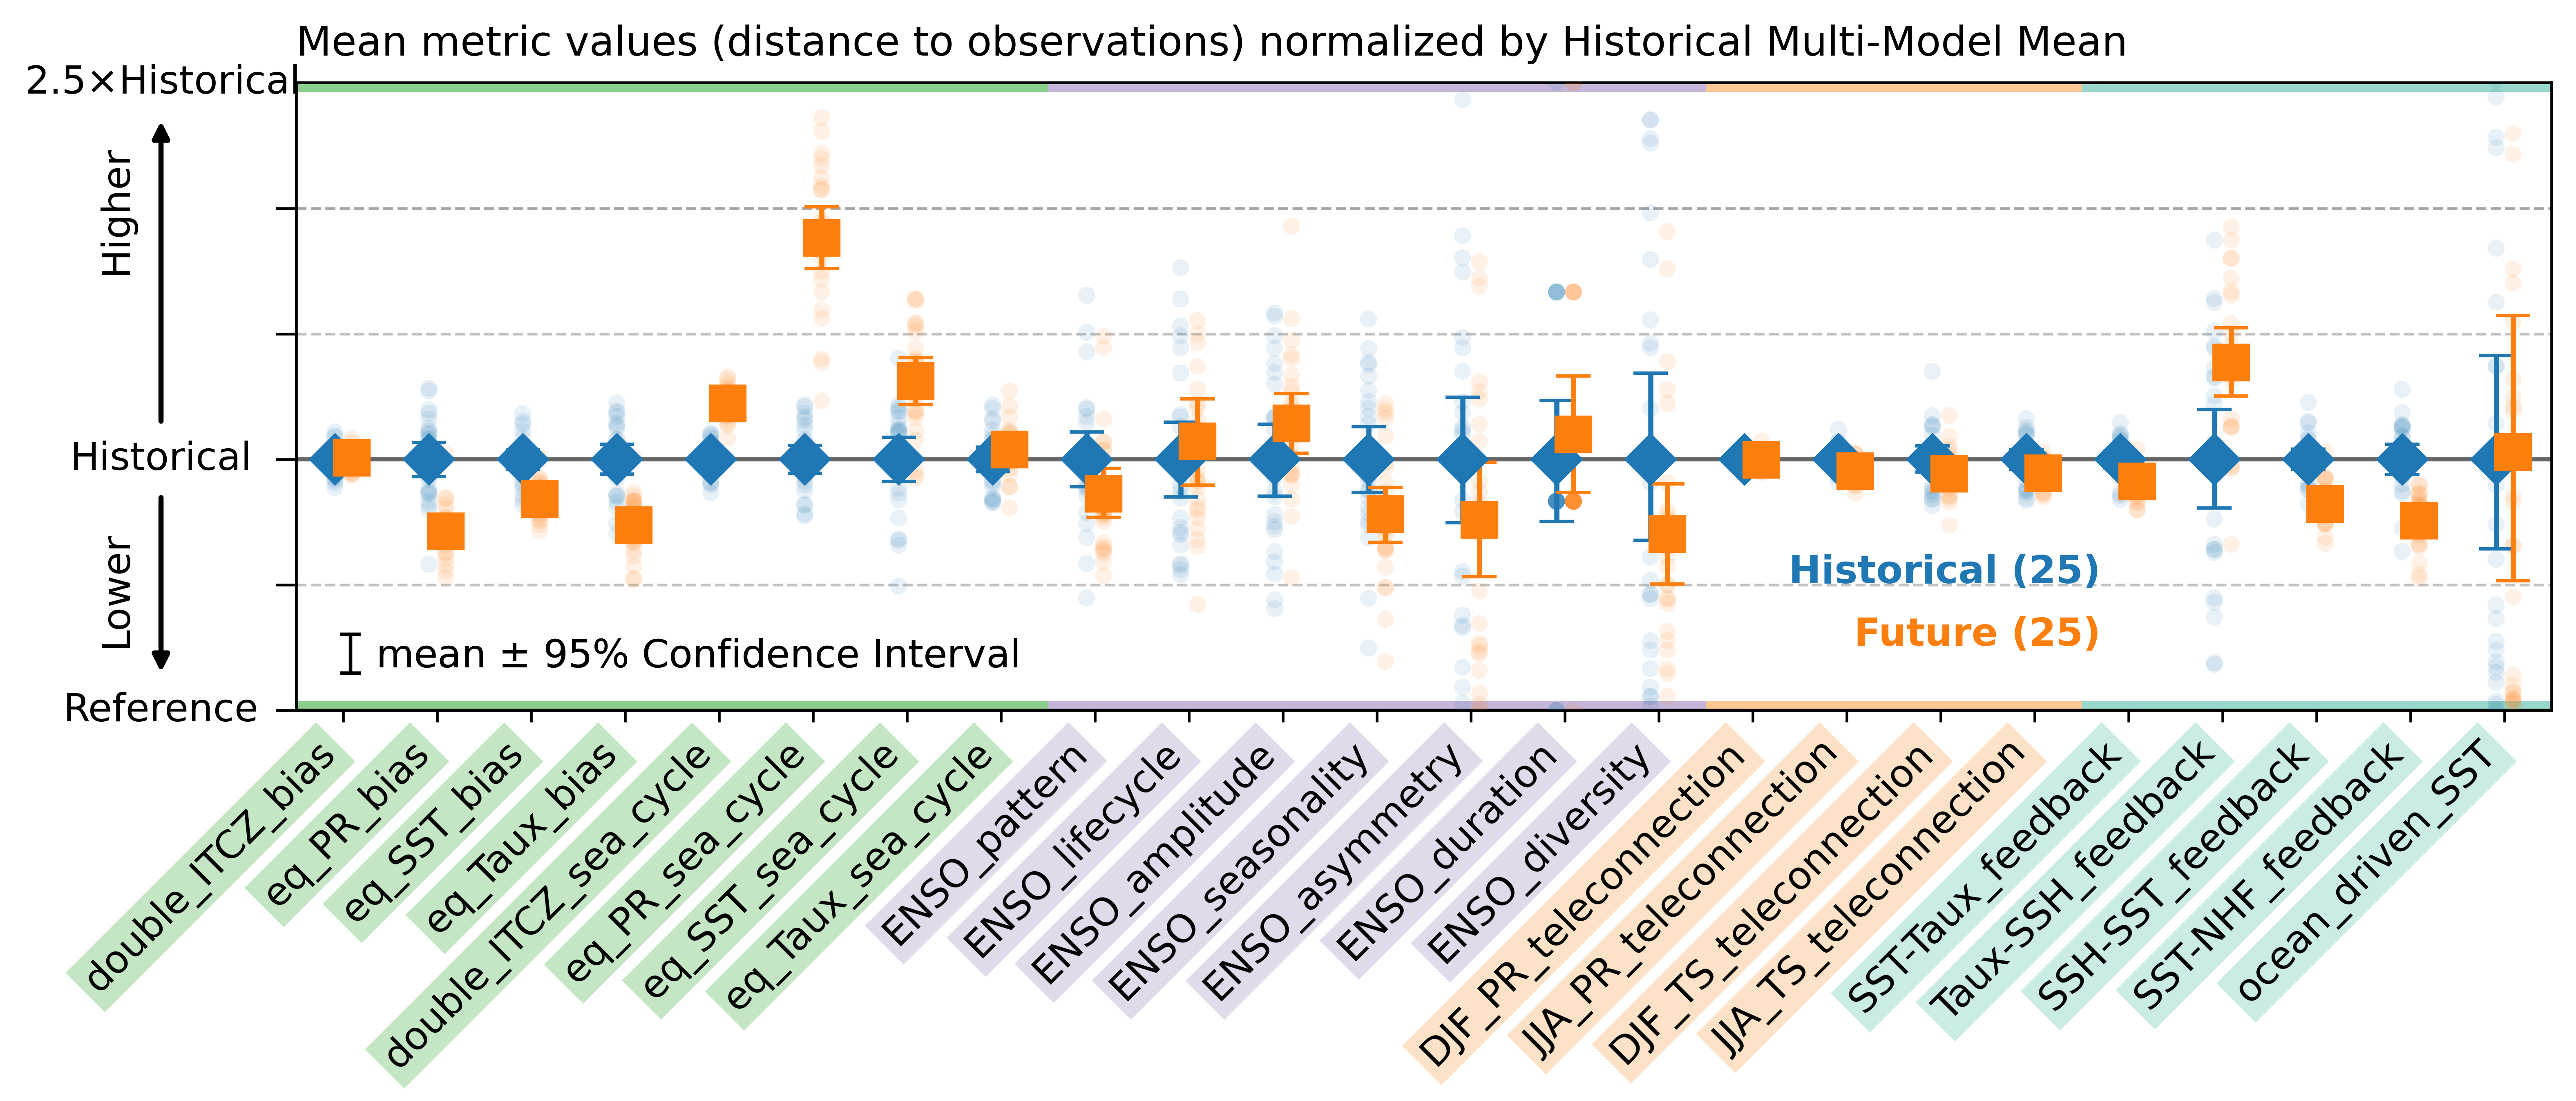

In [32]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    metric_collections = ["ENSO_perf", "ENSO_tel", "ENSO_proc"]

    exp_dict = {
        "CMIP6": {
            "dir": "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric",
            "set": "cmip6.historical.v20210620",
        },
        "E3SMv3-CLIM": {
            "dir": "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric",
            "set": "e3sm.climo.v20260212",
        },
        "E3SMv3-HIST": {
            "dir": "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric",
            "set": "e3sm.historical.v20260212",
        },
        "E3SMv3-FUTURE": {
            "dir": "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric",
            "set": "e3sm.future.v20260212",
        },
    }

    # --- choose what to read ---
    # HIST is now the normalization baseline, so CMIP6 is no longer required
    list_project = ["E3SMv3-HIST", "E3SMv3-FUTURE"]
    list_obs = ["Tropflux", "Tropflux"]
    mod_order = "predefined"
    show_ref_row = True

    # -----------------------------
    # dict_json_path[proj][coll] = "/path/to/file.json"
    # -----------------------------
    dict_json_path = {}
    for proj in list_project:
        dict_json_path[proj] = {}
        mip, rel, cid = exp_dict[proj]["set"].split(".")
        dpath = exp_dict[proj]["dir"]

        for coll in metric_collections:
            fdir = os.path.join(dpath, mip, rel, cid, coll)
            files = glob.glob(os.path.join(fdir, "*.json"))
            if len(files) == 0:
                raise FileNotFoundError(f"No JSON files found under: {fdir}")
            files = sorted(files, key=os.path.getmtime)
            dict_json_path[proj][coll] = files[-1]

    # -----------------------------
    # read metrics
    # -----------------------------
    reader = ENSOMetricReader(
        metric_collections=metric_collections,
        list_project=list_project,
        dict_json_path=dict_json_path,
        list_obs=list_obs,
        mod_order=mod_order,
        show_ref_row=show_ref_row,
    )
    out = reader.read_metrics(return_raw=True)
    _metric_groups, met_names = reader.load_met_names()

    # Debug this once to confirm regex patterns for HIST/FUTURE rows
    print("\n=== First 80 y_names ===")
    for s in out["y_names"][:80]:
        print("  ", s)

    # -----------------------------
    # choose subset + order
    # -----------------------------
    metrics_ordered = OrderedDict([
        ("double_ITCZ_bias", "double_ITCZ_bias"),
        ("eq_PR_bias", "eq_PR_bias"),
        ("eq_SST_bias", "eq_SST_bias"),
        ("eq_Taux_bias", "eq_Taux_bias"),

        ("double_ITCZ_sea_cycle", "double_ITCZ_sea_cycle"),
        ("eq_PR_sea_cycle", "eq_PR_sea_cycle"),
        ("eq_SST_sea_cycle", "eq_SST_sea_cycle"),
        ("eq_Taux_sea_cycle", "eq_Taux_sea_cycle"),

        ("ENSO_pattern", "ENSO_pattern"),
        ("ENSO_lifecycle", "ENSO_lifecycle"),
        ("ENSO_amplitude", "ENSO_amplitude"),
        ("ENSO_seasonality", "ENSO_seasonality"),
        ("ENSO_asymmetry", "ENSO_asymmetry"),
        ("ENSO_duration", "ENSO_duration"),
        ("ENSO_diversity", "ENSO_diversity"),

        ("DJF_PR_teleconnection", "DJF_PR_teleconnection"),
        ("JJA_PR_teleconnection", "JJA_PR_teleconnection"),
        ("DJF_TS_teleconnection", "DJF_TS_teleconnection"),
        ("JJA_TS_teleconnection", "JJA_TS_teleconnection"),

        ("SST-Taux_feedback", "SST-Taux_feedback"),
        ("Taux-SSH_feedback", "Taux-SSH_feedback"),
        ("SSH-SST_feedback", "SSH-SST_feedback"),
        ("SST-NHF_feedback", "SST-NHF_feedback"),
        ("ocean_driven_SST", "ocean_driven_SST"),
    ])

    category_spec = [
        ("mean state bias", ["bias"], "#7fc97f"),
        ("seasonal cycle", ["sea_cycle"], "#7fc97f"),
        ("ENSO", ["ENSO"], "#beaed4"),
        ("teleconnection", ["teleconnection"], "#fdc086"),
        ("feedback", ["feedback"], "#8dd3c7"),
        ("ocean-driven", ["ocean_driven"], "#8dd3c7"),
    ]

    subsetter = ENSOMetricSubset(
        out=out,
        metric_collections=metric_collections,
        met_names=met_names,
    )

    # -----------------------------
    # check '(reference)' row values
    # -----------------------------
    if "(reference)" not in out["y_names"]:
        raise ValueError("'(reference)' not found in out['y_names']; check show_ref_row/list_obs.")
    iref = out["y_names"].index("(reference)")
    print("\n=== Reference row check (RAW, before subsetting) ===")
    for k, coll in enumerate(metric_collections):
        tab = out["tab_raw"][k]
        tab = tab.astype(float).filled(np.nan) if isinstance(tab, np.ma.MaskedArray) else np.asarray(tab, float)
        ref_vals = tab[iref, :]
        n_nan  = int(np.sum(~np.isfinite(ref_vals)))
        n_zero = int(np.sum(np.isfinite(ref_vals) & (ref_vals == 0.0)))
        print(f"[{coll}] n={ref_vals.size}  n_nan={n_nan}  n_zero={n_zero}  "
              f"min={np.nanmin(ref_vals):.3g}  max={np.nanmax(ref_vals):.3g}")

    # -----------------------------
    # subset
    # -----------------------------
    subset_raw, subset_keys, subset_labels, out_sub = subsetter.extract_subset(
        metrics_ordered,
        which="raw",
        debug=True,
        return_out=True,
    )

    print("\nmetric_collections:", metric_collections)
    print("x_names lengths:", [len(x) for x in out_sub["x_names"]])
    print("tab shapes:", [t.shape for t in out_sub["tab"]])

    # -----------------------------
    # check '(reference)' after subsetting
    # -----------------------------
    iref_sub = out_sub["y_names"].index("(reference)")
    print("\n=== Reference row check (RAW, after subsetting) ===")
    for k, coll in enumerate(metric_collections):
        tab = out_sub["tab"][k]
        tab = tab.astype(float).filled(np.nan) if isinstance(tab, np.ma.MaskedArray) else np.asarray(tab, float)
        ref_vals = tab[iref_sub, :]
        n_nan  = int(np.sum(~np.isfinite(ref_vals)))
        n_zero = int(np.sum(np.isfinite(ref_vals) & (ref_vals == 0.0)))
        print(f"[{coll}] n={ref_vals.size}  n_nan={n_nan}  n_zero={n_zero}  "
              f"min={np.nanmin(ref_vals):.3g}  max={np.nanmax(ref_vals):.3g}")

    # -----------------------------
    # plot: Historical baseline, compare Historical vs Future
    # -----------------------------
    title = "Mean metric values (distance to observations) normalized by Historical Multi-Model Mean"
    
    model_groups = {
        "Historical": r"(?i)^v3-LR.*hist",
        "Future": r"(?i)^v3-LR.*future",
    }
    
    group_styles = {
        "Historical": {
            "color": "C0",
            "mean_marker": "D",
            "mean_markersize": 10,
        },
        "Future": {
            "color": "C1",
            "mean_marker": "s",
            "mean_markersize": 10,
        },
    }
    
    show_group_members = True
    show_means_and_ci = True
    dodge = 0.18
    figsize = (10, 4)
    dpi = 600
    fontz = 12
    y_lim = (0, 2.5)
    y_label = ""
    ci_legend_label = r"mean $\pm$ 95% Confidence Interval"
    
    plotter = ENSOOutSubRelativePlotterMulti(
        out_sub=out_sub,
        model_groups=model_groups,
        baseline_group="Historical",
    )
    
    models = plotter.list_models()
    
    print("\n=== Historical models ===")
    for m in models["Historical"]:
        print(m)
    
    print("\n=== Future models ===")
    for m in models["Future"]:
        print(m)
    
    fig, ax = plotter.plot(
        metrics_ordered=metrics_ordered,
        met_names=met_names,
        title=title,
        show_group_members=show_group_members,
        show_means_and_ci=show_means_and_ci,
        category_spec=category_spec,
        dodge=dodge,
        group_styles=group_styles,
        y_lim=y_lim,
        y_label=y_label,
        ci_legend_label=ci_legend_label,
        figsize=figsize,
        fontz=fontz,
        dpi=dpi,
    )
    
    fname = "E3SMv3_Historical_vs_Future_relative_to_Historical"

    pdf_path = os.path.join(FIG_DIR, f"{fname}.pdf")
    fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
    print("Wrote:")
    print(" ", pdf_path)
    
    plt.show()
    plt.close(fig)
    